# 02 · Хайгуулын шинжилгээ (EDA)

Энэ notebook-д бид өгөгдлийг 19 өөр хэтийн хараагаар шинжилнэ. **Plotly** болон
**matplotlib** ашигласан интерактив graph-уудтай.

Бүх chart-уудын гарчиг, тэнхлэгийн нэр Монголоор.


In [1]:
# Setup + helpers
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from analysis import load_all, applications_enriched, students_enriched

# Mongolian Cyrillic-ийг дэмжих фонт
plt.rcParams['font.family'] = ['Segoe UI', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.05)

dfs = load_all()
apps = applications_enriched(dfs)
students = students_enriched(dfs)
print(f'Өргөдөл: {len(apps):,} | Оюутан: {len(students):,} | Их сургууль: {len(dfs["universities"])} | Хөтөлбөр: {len(dfs["programs"])}')


Өргөдөл: 2,250 | Оюутан: 1,500 | Их сургууль: 50 | Хөтөлбөр: 200


## 1. Өргөдлийн тоо жилээр (2019–2025)

In [2]:
yearly = apps.groupby('apply_year').size().reset_index(name='count')
fig = px.bar(yearly, x='apply_year', y='count',
             title='Өргөдлийн тоо жилээр (Mongolia → China)',
             labels={'apply_year': 'Жил', 'count': 'Өргөдлийн тоо'},
             color='count', color_continuous_scale='Viridis', text='count')
fig.add_annotation(x=2020, y=yearly[yearly.apply_year==2020]['count'].iloc[0]+30,
                   text='COVID-19 хил хаагдав', showarrow=True, arrowhead=2)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, height=500)
fig.show()


## 2. Аймгийн тархалт (Mongolia map heatmap)

In [3]:
aimag_counts = students['aimag'].value_counts().reset_index()
aimag_counts.columns = ['aimag', 'count']
aimag_counts['log_count'] = np.log1p(aimag_counts['count'])
fig = px.bar(aimag_counts.head(15), x='count', y='aimag', orientation='h',
             title='Оюутны тоо аймгаар (топ 15)',
             labels={'count': 'Оюутны тоо', 'aimag': 'Аймаг'},
             color='count', color_continuous_scale='Plasma')
fig.update_layout(height=520, yaxis={'categoryorder': 'total ascending'})
fig.show()
print(f'\nУлаанбаатарын эзлэх хувь: {(students["aimag"]=="Улаанбаатар").mean()*100:.1f}%')



Улаанбаатарын эзлэх хувь: 70.1%


## 3. Улаанбаатарын дүүргүүдийн задаргаа

In [4]:
ub = students[students['aimag'] == 'Улаанбаатар']
ub_dist = ub['district'].value_counts().reset_index()
ub_dist.columns = ['district', 'count']
fig = px.bar(ub_dist, x='district', y='count',
             title='УБ-гийн дүүргүүдийн тархалт',
             labels={'district': 'Дүүрэг', 'count': 'Оюутны тоо'},
             color='count', color_continuous_scale='Sunset')
fig.update_layout(height=460)
fig.show()


## 4. Насны тархалт (өргөдөл өгөх үед)

In [5]:
fig = px.histogram(students, x='age_at_register', nbins=15,
                   title='Бүртгүүлэх үеийн нас',
                   labels={'age_at_register': 'Нас', 'count': 'Оюутны тоо'},
                   color_discrete_sequence=['#7F77DD'])
fig.update_layout(height=440, bargap=0.05)
fig.show()
print(f'\n17-19 настай эзлэх: {((students["age_at_register"]>=17)&(students["age_at_register"]<=19)).mean()*100:.1f}%')



17-19 настай эзлэх: 86.6%


## 5. HSK түвшингийн тархалт жил тутамд

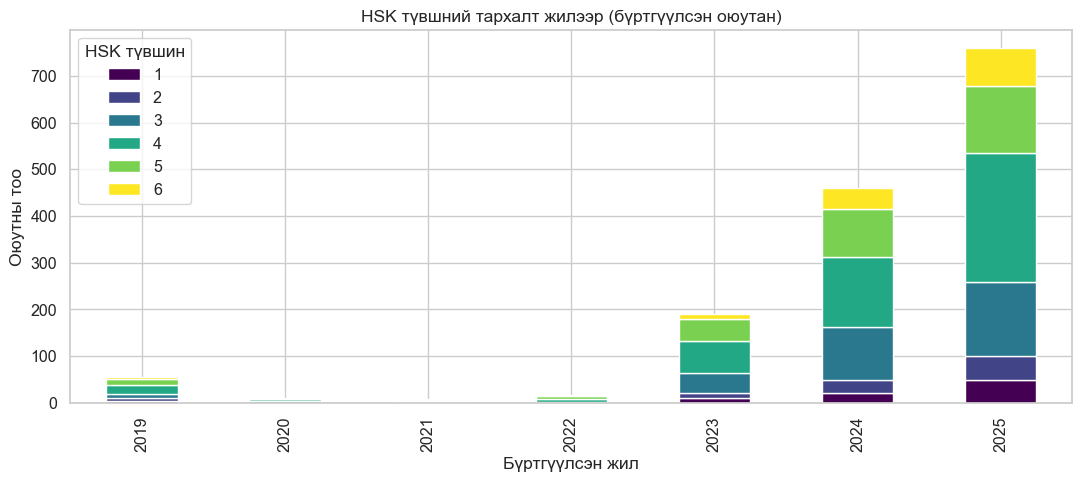

In [6]:
hsk_year = students.groupby(['register_year', 'hsk_level']).size().unstack(fill_value=0)
hsk_year.plot(kind='bar', stacked=True, figsize=(11, 5),
              colormap='viridis')
plt.title('HSK түвшний тархалт жилээр (бүртгүүлсэн оюутан)')
plt.xlabel('Бүртгүүлсэн жил')
plt.ylabel('Оюутны тоо')
plt.legend(title='HSK түвшин', loc='upper left')
plt.tight_layout()
plt.show()


## 6. Топ 10 их сургууль

In [7]:
top10 = apps['uni_name'].value_counts().head(10).reset_index()
top10.columns = ['uni_name', 'count']
fig = px.bar(top10, x='count', y='uni_name', orientation='h',
             title='Топ 10 их сургууль (өргөдлийн тоогоор)',
             labels={'count': 'Өргөдөл', 'uni_name': 'Их сургууль'},
             color='count', color_continuous_scale='Teal')
fig.update_layout(height=520, yaxis={'categoryorder': 'total ascending'})
fig.show()


## 7. Мэргэжлийн чиглэлийн чиг хандлага

In [8]:
field_year = apps.groupby(['apply_year', 'field']).size().unstack(fill_value=0)
fig = px.line(field_year.reset_index().melt(id_vars='apply_year', var_name='field', value_name='count'),
              x='apply_year', y='count', color='field',
              title='Мэргэжлийн чиглэлүүдийн өсөлт жилээр',
              labels={'apply_year': 'Жил', 'count': 'Өргөдөл', 'field': 'Салбар'})
fig.update_layout(height=480)
fig.show()


## 8. HSK × GPA × элсэлтийн харьцаа

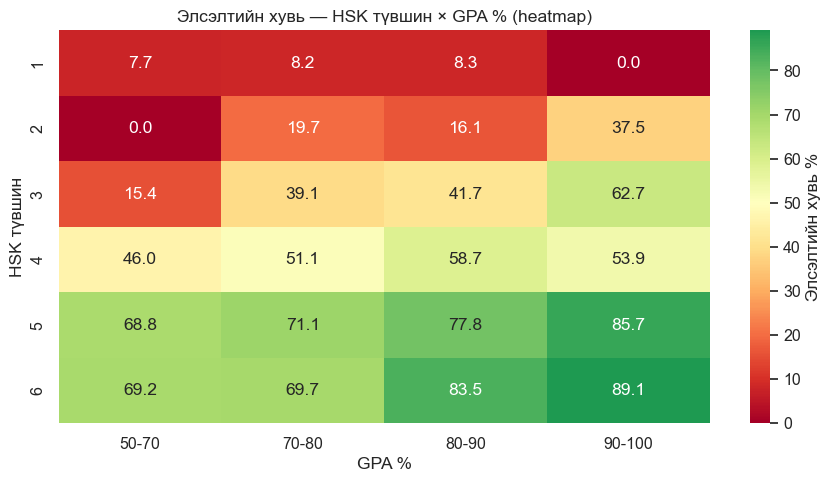

In [9]:
apps['gpa_band'] = pd.cut(apps['gpa_percent'], bins=[50, 70, 80, 90, 100],
                            labels=['50-70', '70-80', '80-90', '90-100'])
heatmap = apps.groupby(['hsk_level', 'gpa_band'], observed=True)['is_accepted'].mean().unstack() * 100
plt.figure(figsize=(9, 5))
sns.heatmap(heatmap, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            cbar_kws={'label': 'Элсэлтийн хувь %'})
plt.title('Элсэлтийн хувь — HSK түвшин × GPA % (heatmap)')
plt.xlabel('GPA %')
plt.ylabel('HSK түвшин')
plt.tight_layout()
plt.show()


## 9. Сургалтын төлбөрийн тархалт сургуулийн tier-ээр

In [10]:
progs = dfs['programs'].merge(dfs['universities'][['uni_id', 'tier']], on='uni_id')
fig = px.violin(progs, x='tier', y='tuition_yuan',
                category_orders={'tier': ['C9', '985', '211', 'Provincial']},
                title='Сургалтын төлбөрийн тархалт tier тус бүрээр',
                labels={'tier': 'Tier', 'tuition_yuan': 'Төлбөр (юань / жил)'},
                color='tier', box=True)
fig.update_layout(height=460)
fig.show()


## 10. Тэтгэлгийн төрлүүдийн задаргаа

In [11]:
sch = dfs['scholarships']
sch_summary = sch.groupby('scholarship_type').agg(
    count=('scholarship_id', 'count'),
    total_yuan=('amount_yuan', 'sum'),
    avg_yuan=('amount_yuan', 'mean'),
).reset_index().sort_values('count', ascending=False)
fig = px.pie(sch_summary, values='count', names='scholarship_type',
             title='Тэтгэлгийн төрлүүдийн эзлэх хувь',
             hole=0.45)
fig.update_traces(textinfo='label+percent')
fig.update_layout(height=440)
fig.show()
sch_summary.style.format({'total_yuan': '{:,.0f}', 'avg_yuan': '{:,.0f}'})


,scholarship_type,count,total_yuan,avg_yuan
2,CSC Partial,145,"3,126,869","21,565"
5,University Merit,130,"1,970,003","15,154"
3,Confucius Institute,82,"1,048,701","12,789"
1,CSC Full,59,"3,531,675","59,859"
0,ANKO Bridge,53,"365,594","6,898"
4,Provincial,47,"660,973","14,063"


## 11. Хүйсийн тархалт мэргэжлээр

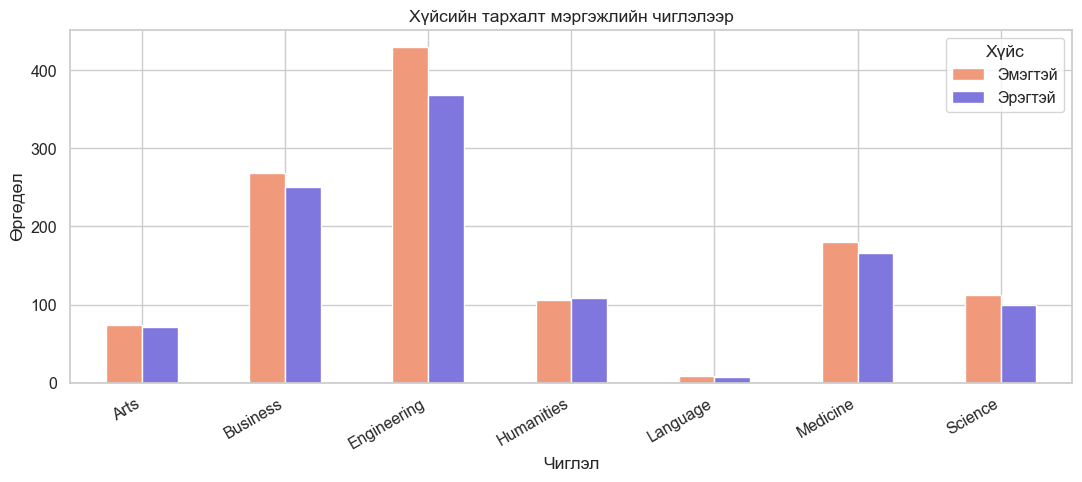

In [12]:
gender_field = apps.groupby(['field', 'gender']).size().unstack(fill_value=0)
gender_field.plot(kind='bar', figsize=(11, 5), color=['#F0997B', '#7F77DD'])
plt.title('Хүйсийн тархалт мэргэжлийн чиглэлээр')
plt.xlabel('Чиглэл')
plt.ylabel('Өргөдөл')
plt.legend(title='Хүйс', labels=['Эмэгтэй', 'Эрэгтэй'])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 12. Тоон хувьсагчдын correlation matrix

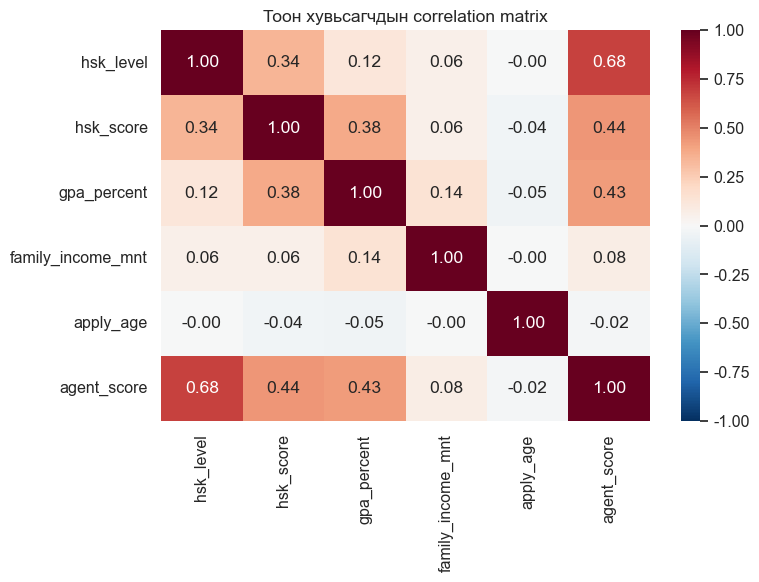

In [13]:
num_cols = ['hsk_level', 'hsk_score', 'gpa_percent', 'family_income_mnt', 'apply_age', 'agent_score']
corr = apps[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Тоон хувьсагчдын correlation matrix')
plt.tight_layout()
plt.show()


## 13. ANKO 4 хөтөлбөрийн тархалт

In [14]:
prog_share = apps['anko_program_type'].value_counts(normalize=True).reset_index()
prog_share.columns = ['type', 'pct']
prog_share['pct'] = prog_share['pct'] * 100
fig = px.pie(prog_share, values='pct', names='type',
             title='ANKO-гийн 4 хөтөлбөрийн нийт эзлэх хувь',
             hole=0.5,
             color_discrete_sequence=['#7F77DD', '#5DCAA5', '#F0997B', '#F5D67B'])
fig.update_traces(textinfo='label+percent')
fig.update_layout(height=460)
fig.show()


## 14. 6+6 хөтөлбөрийн өсөлт жилээр (stacked area)

In [15]:
prog_year = apps.groupby(['apply_year', 'anko_program_type']).size().unstack(fill_value=0)
prog_pct = prog_year.div(prog_year.sum(axis=1), axis=0) * 100
fig = go.Figure()
colors = {'6+6': '#7F77DD', '1+4': '#5DCAA5', 'Fall Bachelor': '#F0997B', 'Master/PhD': '#F5D67B'}
for col in ['6+6', '1+4', 'Fall Bachelor', 'Master/PhD']:
    if col in prog_pct.columns:
        fig.add_trace(go.Scatter(x=prog_pct.index, y=prog_pct[col],
                                 stackgroup='one', name=col, line=dict(color=colors[col])))
fig.update_layout(title='Хөтөлбөр тус бүрийн эзлэх хувь жилээр (%)',
                  xaxis_title='Жил', yaxis_title='Хувь', height=480)
fig.show()


## 15. Хөтөлбөр тус бүрийн элсэлтийн хувь

In [16]:
accept_prog = apps.groupby('anko_program_type')['is_accepted'].mean() * 100
accept_prog = accept_prog.reset_index().sort_values('is_accepted', ascending=False)
fig = px.bar(accept_prog, x='anko_program_type', y='is_accepted',
             title='Элсэлтийн хувь хөтөлбөрөөр',
             labels={'anko_program_type': 'Хөтөлбөр', 'is_accepted': 'Элсэлтийн хувь %'},
             color='is_accepted', color_continuous_scale='Viridis', text='is_accepted')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=460)
fig.show()


## 16. HSK түвшин × хөтөлбөр (heatmap)

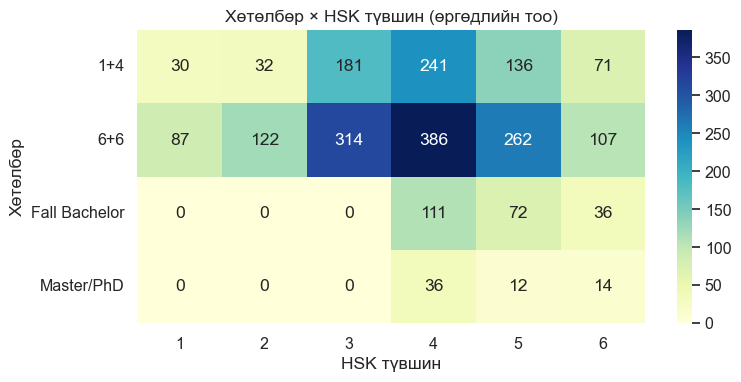

In [17]:
hsk_prog = apps.groupby(['anko_program_type', 'hsk_level']).size().unstack(fill_value=0)
plt.figure(figsize=(8, 4))
sns.heatmap(hsk_prog, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Хөтөлбөр × HSK түвшин (өргөдлийн тоо)')
plt.xlabel('HSK түвшин')
plt.ylabel('Хөтөлбөр')
plt.tight_layout()
plt.show()


## 17. Шийдвэр гартал (decision_days) хөтөлбөрөөр (boxplot)

In [18]:
fig = px.box(apps, x='anko_program_type', y='decision_days',
             title='Шийдвэр гартал (өдрөөр) хөтөлбөрөөр',
             labels={'anko_program_type': 'Хөтөлбөр', 'decision_days': 'Өдрийн тоо'},
             color='anko_program_type')
fig.update_layout(height=460, showlegend=False)
fig.show()


## 18. Сургуулийн төрөл vs хөтөлбөр сонголт

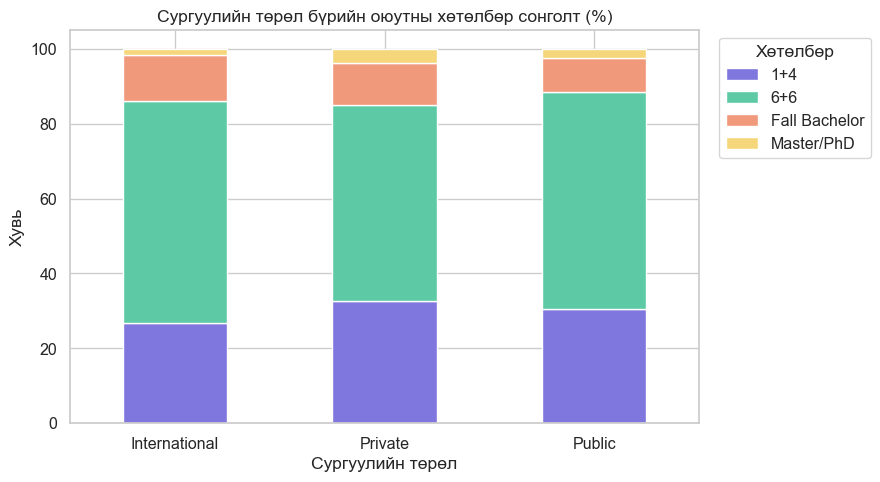

In [19]:
school_prog = apps.groupby(['school_type', 'anko_program_type']).size().unstack(fill_value=0)
school_pct = school_prog.div(school_prog.sum(axis=1), axis=0) * 100
school_pct.plot(kind='bar', stacked=True, figsize=(9, 5),
                color=['#7F77DD', '#5DCAA5', '#F0997B', '#F5D67B'])
plt.title('Сургуулийн төрөл бүрийн оюутны хөтөлбөр сонголт (%)')
plt.xlabel('Сургуулийн төрөл')
plt.ylabel('Хувь')
plt.legend(title='Хөтөлбөр', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 19. УБ vs аймаг — GPA, HSK, орлогын харьцуулалт

C:\Users\NewTech\AppData\Local\Temp\ipykernel_23012\3402729312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=students_geo, x='region', y='gpa_percent', ax=axes[0], palette=['#7F77DD','#F0997B'])
C:\Users\NewTech\AppData\Local\Temp\ipykernel_23012\3402729312.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=students_geo, x='region', y='hsk_level', ax=axes[1], palette=['#7F77DD','#F0997B'])
C:\Users\NewTech\AppData\Local\Temp\ipykernel_23012\3402729312.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=students_geo, x=

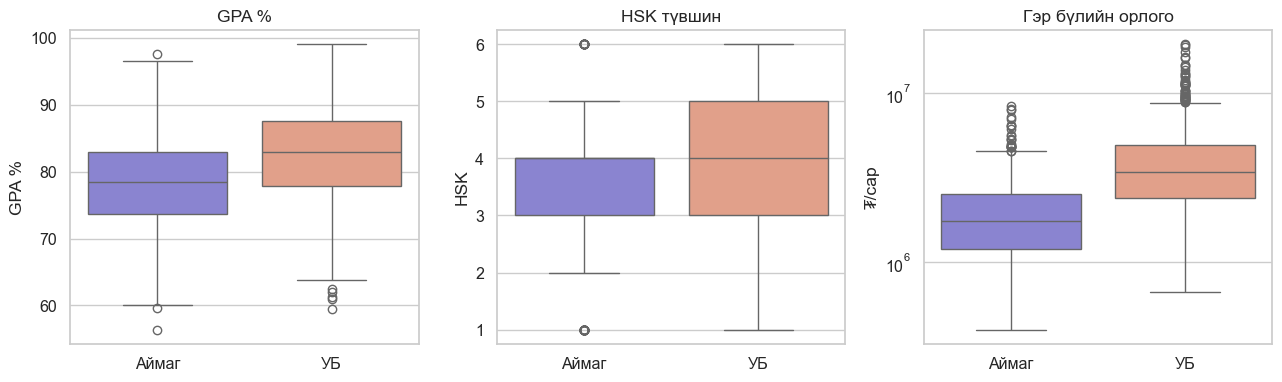

In [20]:
students_geo = students.copy()
students_geo['region'] = np.where(students_geo['aimag']=='Улаанбаатар', 'УБ', 'Аймаг')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.boxplot(data=students_geo, x='region', y='gpa_percent', ax=axes[0], palette=['#7F77DD','#F0997B'])
axes[0].set_title('GPA %')
axes[0].set_xlabel(''); axes[0].set_ylabel('GPA %')
sns.boxplot(data=students_geo, x='region', y='hsk_level', ax=axes[1], palette=['#7F77DD','#F0997B'])
axes[1].set_title('HSK түвшин')
axes[1].set_xlabel(''); axes[1].set_ylabel('HSK')
sns.boxplot(data=students_geo, x='region', y='family_income_mnt', ax=axes[2], palette=['#7F77DD','#F0997B'])
axes[2].set_title('Гэр бүлийн орлого')
axes[2].set_xlabel(''); axes[2].set_ylabel('₮/сар')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()


## Дүгнэлт

19 graph-аас гарсан гол ажиглалтууд:

1. **2025 он peak** — өргөдлийн тоо 2019-тэй харьцуулахад 25+ дахин өссөн.
2. **УБ давамгайлал** — оюутны 70% хотынх, дотроо Хан-Уул дүүрэг тэргүүн.
3. **17-19 нас** — оюутны 85% энэ насны хязгаарт.
4. **6+6 хөтөлбөр** — 2019 онд 35%-аас 2024 онд 55% хүртэл өсчээ.
5. **HSK 5+** оюутнууд хамгийн өндөр элсэлтийн хувьтай (~78%).

Дараагийн notebook-д статистик шинжилгээ хийнэ (`03_statistics.ipynb`).
